##Telecom X – Análisis de Evasión de Clientes (Churn)

**Objetivo:**
Examinar el comportamiento de cancelación de clientes (churn) mediante el análisis de variables demográficas, características de los servicios contratados y datos de facturación, con el fin de detectar patrones relevantes que contribuyan al diseño de estrategias efectivas de retención.

**Fuente de datos:**
Conjunto de datos en formato JSON obtenido desde el repositorio oficial del challenge, accedido directamente a través de su enlace RAW/API.

**Estructura del proyecto:**

1.  Obtención de datos mediante API
2.  Análisis preliminar y entendimiento del dataset
3.  Depuración, tratamiento de datos y validación de inconsistencias
4.  Creación de nuevas variables: Cuentas_Diarias
5.  Análisis Exploratorio de Datos (EDA)
6.  Evaluación de correlaciones entre variables (opcional)
7.  Conclusiones finales: hallazgos clave, insights estratégicos y recomendaciones accionables



##📌 Extracción

1.  Obtención de datos mediante API

Se cargan los datos directamente desde la API (JSON) y se convierten a un DataFrame de Pandas.

In [41]:
# importamos las bibliotecas necesarias para importar archivo JSON
import pandas as pd

# Enlace RAW del dataset (API)
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/refs/heads/main/TelecomX_Data.json"
df_raw = pd.read_json(url)


In [31]:
df.head()


,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


##🔧 Transformación

2.  Análisis preliminar y entendimiento del dataset

Ahora que has extraído los datos, es fundamental comprender la estructura del dataset y el significado de sus columnas.

In [42]:
# revisión previa a la normalización
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [33]:
df.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


En esta etapa se revisan los datos para detectar posibles errores que afecten el análisis, como valores faltantes, duplicados, formatos incorrectos o categorías inconsistentes.


El JSON contiene campos anidados. Para facilitar la manipulación, se normaliza la estructura a un DataFrame tabular.

In [46]:
df_normalized = pd.json_normalize(df_raw.to_dict(orient="records"))
df_normalized.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [47]:
#Conoce el conjunto de datos
df_normalized.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer.gender            7267 non-null   object 
 3   customer.SeniorCitizen     7267 non-null   int64  
 4   customer.Partner           7267 non-null   object 
 5   customer.Dependents        7267 non-null   object 
 6   customer.tenure            7267 non-null   int64  
 7   phone.PhoneService         7267 non-null   object 
 8   phone.MultipleLines        7267 non-null   object 
 9   internet.InternetService   7267 non-null   object 
 10  internet.OnlineSecurity    7267 non-null   object 
 11  internet.OnlineBackup      7267 non-null   object 
 12  internet.DeviceProtection  7267 non-null   object 
 13  internet.TechSupport       7267 non-null   objec

In [50]:
df_normalized.dtypes

,0
customerID,object
Churn,object
customer.gender,object
customer.SeniorCitizen,int64
customer.Partner,object
customer.Dependents,object
customer.tenure,int64
phone.PhoneService,object
phone.MultipleLines,object
internet.InternetService,object


Análisis de la Estructura de los Datos

Los datos están organizados en un formato jerárquico (diccionario dentro de diccionario), conteniendo la siguiente información:

1. Identificación del Cliente
* 'customerID': Identificador único del cliente.
* 'Churn': Indica si el cliente canceló el servicio (Yes o No).
2. Información del Cliente ('customer')
* 'gender': Género del cliente (Male o Female).
* 'SeniorCitizen': Indica si el cliente es una persona mayor (0 = No, 1 = Sí).
* 'Partner': Si el cliente tiene pareja.
* 'Dependents': Si el cliente tiene dependientes.
* 'tenure': Tiempo de permanencia como cliente (en meses).
3. Servicios de Telefonía ('phone')
* 'PhoneService': Indica si el cliente posee servicio de teléfono (Yes o No).
* 'MultipleLines': Si posee múltiples líneas telefónicas.
4. Servicios de Internet ('internet')
* Tipo de servicio de internet contratado (DSL, Fiber optic, No).
* Servicios adicionales (OnlineSecurity, OnlineBackup, DeviceProtection, * * * * TechSupport, StreamingTV, StreamingMovies).
5. Información de la Cuenta ('account')
* 'Contract': Tipo de contrato (Month-to-month, One year, Two year).
* 'PaperlessBilling': Si el cliente recibe facturas electrónicas.
* 'PaymentMethod': Método de pago (Bank transfer, Credit card, Electronic check, Mailed check).
*'Charges':
* 'Monthly': Valor mensual cobrado.
* 'Total': Valor total pagado por el cliente.

3.  Depuración, tratamiento de datos y validación de inconsistencias

Se verifican datos faltantes, registros repetidos, formatos incorrectos y coherencia en las categorías para garantizar un análisis confiable.

In [52]:
# Verificación de datos únicos

for col in df_normalized.columns:
  print(f'{col}: {df_normalized[col].nunique()}')

  if df_normalized[col].nunique() < 50:
    print(f'{df_normalized[col].value_counts()}')
    print('-' * 50)

customerID: 7267
Churn: 3
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64
--------------------------------------------------
customer.gender: 2
customer.gender
Male      3675
Female    3592
Name: count, dtype: int64
--------------------------------------------------
customer.SeniorCitizen: 2
customer.SeniorCitizen
0    6085
1    1182
Name: count, dtype: int64
--------------------------------------------------
customer.Partner: 2
customer.Partner
No     3749
Yes    3518
Name: count, dtype: int64
--------------------------------------------------
customer.Dependents: 2
customer.Dependents
No     5086
Yes    2181
Name: count, dtype: int64
--------------------------------------------------
customer.tenure: 73
phone.PhoneService: 2
phone.PhoneService
Yes    6560
No      707
Name: count, dtype: int64
--------------------------------------------------
phone.MultipleLines: 3
phone.MultipleLines
No                  3495
Yes                 3065
No phone service     707
Name:

In [55]:
# Verificación de datos duplicados

print(f'Cantidad de duplicados: {df_normalized.duplicated().sum()}')

Cantidad de duplicados: 0


In [59]:
# Verificación de datos nulos

for col in df.columns:
  print(f'{col}: {df[col].isnull().sum()}')

customerID: 0
Churn: 0
customer: 0
phone: 0
internet: 0
account: 0


In [53]:
# Limpieza de la variable objetivo: normalizo y filtro valores válidos (Yes/No)
df_normalized['Churn'] = df_normalized['Churn'].astype(str).str.strip()

df_normalized = df_normalized[df_normalized['Churn'].isin(['Yes', 'No'])].copy()

df_normalized['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


In [62]:
# Transformación de columna account.Charges.Total de object a float

df_normalized['account.Charges.Total'] = df_normalized['account.Charges.Total'].apply(pd.to_numeric, errors='coerce')
print(df_normalized['account.Charges.Total'].dtype)
df_normalized.info()

float64
<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7043 non-null   object 
 1   Churn                      7043 non-null   object 
 2   customer.gender            7043 non-null   object 
 3   customer.SeniorCitizen     7043 non-null   int64  
 4   customer.Partner           7043 non-null   object 
 5   customer.Dependents        7043 non-null   object 
 6   customer.tenure            7043 non-null   int64  
 7   phone.PhoneService         7043 non-null   object 
 8   phone.MultipleLines        7043 non-null   object 
 9   internet.InternetService   7043 non-null   object 
 10  internet.OnlineSecurity    7043 non-null   object 
 11  internet.OnlineBackup      7043 non-null   object 
 12  internet.DeviceProtection  7043 non-null   object 
 13  internet.TechSupport       7043 non-null   ob

In [63]:
df_normalized['account.Charges.Monthly']

#Asumiendo un promedio de 30 días por mes.

,account.Charges.Monthly
0,65.60
1,59.90
2,73.90
3,98.00
4,83.90
...,...
7262,55.15
7263,85.10
7264,50.30
7265,67.85


4.  Creación de nuevas variables: Cuentas_Diarias (Opcional)

Con el objetivo de obtener una visión más granular del comportamiento de facturación, se creó la variable Cuentas_Diarias, derivada de la facturación mensual. Esta transformación permite analizar el impacto del costo del servicio en una escala temporal más detallada y evaluar su posible relación con la cancelación del servicio.

In [66]:
df_normalized["Cuentas_Diarias"] = df_normalized["account.Charges.Monthly"] / 30

#Verificamos si se creo

df_normalized.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.186667
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,1.996667
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.463333
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.266667
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.796667


#📊 Carga y análisis


5.  Análisis Exploratorio de Datos (EDA)

A continuación se presentan análisis descriptivos y visualizaciones para identificar patrones asociados a la evasión, calculando métricas como media, mediana, desviación estándar y otras medidas que ayuden a comprender mejor la distribución y el comportamiento de los clientes.


In [68]:


df_normalized[['customer.tenure','account.Charges.Monthly','account.Charges.Total','Cuentas_Diarias']].describe()

,customer.tenure,account.Charges.Monthly,account.Charges.Total,Cuentas_Diarias
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,2.158723
std,24.559481,30.090047,2266.794470,1.003002
min,0.000000,18.250000,0.000000,0.608333
25%,9.000000,35.500000,398.550000,1.183333
50%,29.000000,70.350000,1394.550000,2.345000
75%,55.000000,89.850000,3786.600000,2.995000
max,72.000000,118.750000,8684.800000,3.958333


Se visualiza la proporción de clientes que permanecen vs. los que abandonan.

In [91]:
churn_pct = df_normalized['Churn'].value_counts(normalize=True) * 100
churn_pct


,proportion
Churn,
No,73.463013
Yes,26.536987


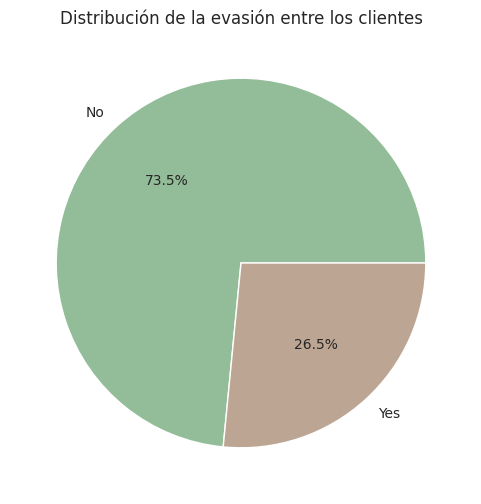

In [97]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6))

colores = ['#93bd99', '#bda593']

churn_pct.plot(
    kind='pie',
    autopct='%1.1f%%',
    ax=ax,
    colors=colores
)

ax.set_title('Distribución de la evasión entre los clientes')
ax.set_ylabel('')

plt.show()


6.  Evaluación de correlaciones entre variables (opcional)

Se analiza churn según variables categóricas para identificar perfiles con mayor tendencia a abandono.

* Por contrato
* Por género
* Por método de pago


In [98]:
churn_by_contract = (
    df_normalized
    .groupby('account.Contract')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percentage')
    .reset_index()
)
churn_by_contract


,account.Contract,Churn,percentage
0,Month-to-month,No,57.290323
1,Month-to-month,Yes,42.709677
2,One year,No,88.730482
3,One year,Yes,11.269518
4,Two year,No,97.168142
5,Two year,Yes,2.831858


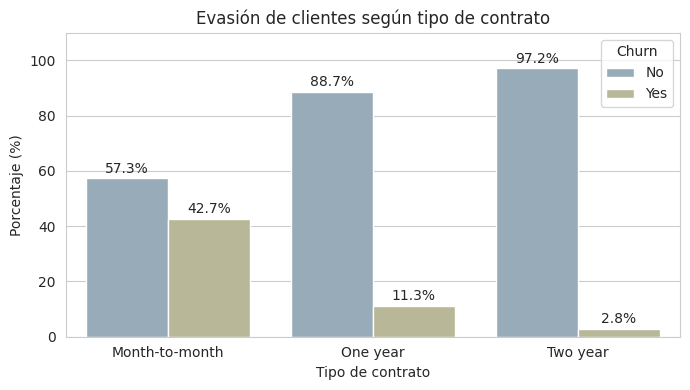

In [89]:
plt.figure(figsize=(7,4))

# Define the order for contract types for better visualization
order_contract = ['Month-to-month', 'One year', 'Two year']

ax = sns.barplot(
    data=churn_by_contract,
    x='account.Contract',
    y='percentage',
    hue='Churn',
    order=order_contract,
    palette={
        'No': '#93acbd',
        'Yes': '#bdbc93'
    }
)

plt.title('Evasión de clientes según tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Porcentaje (%)')

# etiquetas
for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', padding=2)

plt.ylim(0, 110)
plt.legend(title='Churn', loc='upper right')
plt.tight_layout()
plt.show()

In [101]:
churn_by_gender = (
    df_normalized
    .groupby('customer.gender')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percentage')
    .reset_index()
)
churn_by_gender

,customer.gender,Churn,percentage
0,Female,No,73.079128
1,Female,Yes,26.920872
2,Male,No,73.839662
3,Male,Yes,26.160338


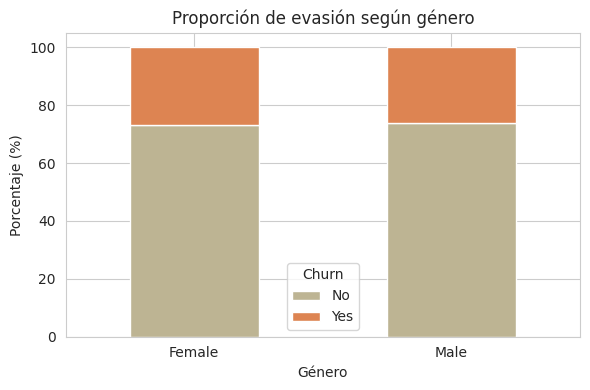

In [103]:
import matplotlib.pyplot as plt

pivot_gender = churn_by_gender.pivot(
    index='customer.gender',
    columns='Churn',
    values='percentage'
)

# Normalizar para que cada fila sume 100%
pivot_gender_norm = pivot_gender.div(pivot_gender.sum(axis=1), axis=0) * 100

pivot_gender_norm.plot(
    kind='bar',
    stacked=True,
    figsize=(6,4),
    color=['#bdb493', '#DD8452']
)

plt.title('Proporción de evasión según género')
plt.xlabel('Género')
plt.ylabel('Porcentaje (%)')
plt.legend(title='Churn')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [99]:
churn_by_payment = (
    df_normalized
    .groupby('account.PaymentMethod')['Churn']
    .value_counts(normalize=True)
    .mul(100)
    .rename('percentage')
    .reset_index()
)
churn_by_payment

,account.PaymentMethod,Churn,percentage
0,Bank transfer (automatic),No,83.290155
1,Bank transfer (automatic),Yes,16.709845
2,Credit card (automatic),No,84.756899
3,Credit card (automatic),Yes,15.243101
4,Electronic check,No,54.714588
5,Electronic check,Yes,45.285412
6,Mailed check,No,80.893300
7,Mailed check,Yes,19.106700


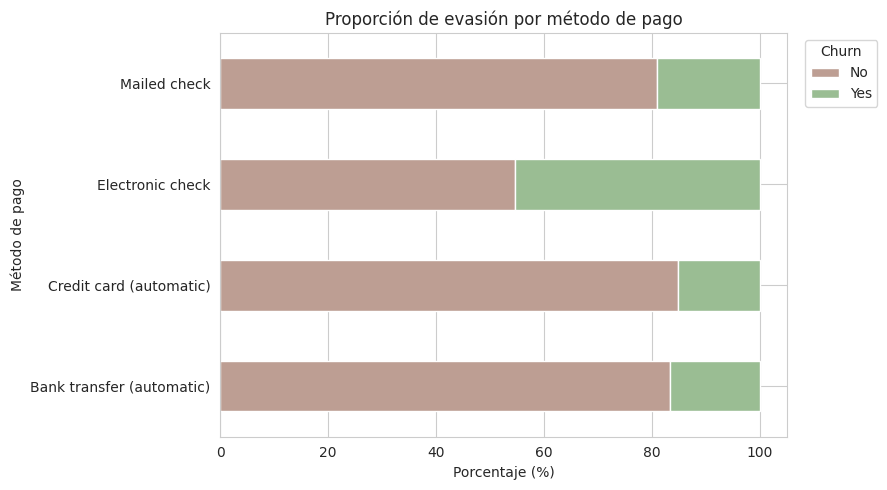

In [107]:
import matplotlib.pyplot as plt
import pandas as pd

# Pivotear los datos
pivot_df = churn_by_payment.pivot(
    index='account.PaymentMethod',
    columns='Churn',
    values='percentage'
)

# Crear gráfico
pivot_df.plot(
    kind='barh',
    stacked=True,
    figsize=(9, 5),
    color=['#bd9e93', '#9abd93']
)

plt.title('Proporción de evasión por método de pago')
plt.xlabel('Porcentaje (%)')
plt.ylabel('Método de pago')
plt.legend(title='Churn', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

Conteo de evasión por variables numéricas

En este paso, explora cómo las variables numéricas, como "total gastado" o "tiempo de contrato", se distribuyen entre los clientes que cancelaron (evasión) y los que no cancelaron.

Este análisis ayuda a entender si ciertos valores numéricos están más asociados con la evasión, proporcionando insights sobre los factores que influyen en el comportamiento de los clientes.

* Antigüedad (tenure) vs churn
* Cargos mensuales vs churn
* Total gastado vs churn

In [108]:
df_normalized.groupby('Churn')['customer.tenure'].describe()



,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.569965,24.113777,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


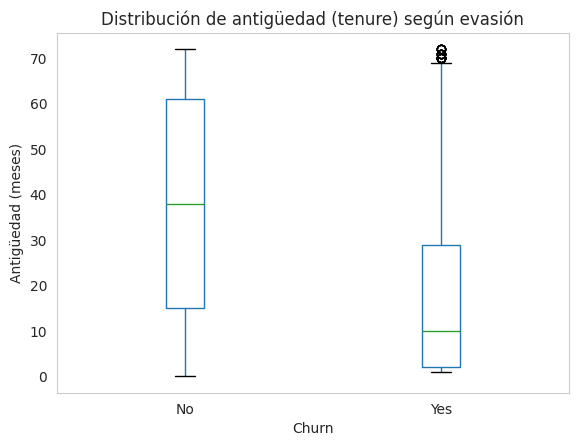

In [109]:
df_normalized.boxplot(column='customer.tenure', by='Churn', grid=False)
plt.title('Distribución de antigüedad (tenure) según evasión')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Antigüedad (meses)')
plt.show()

Los clientes que abandonan el servicio tienden a presentar menor antigüedad. Esto sugiere que el churn ocurre con mayor frecuencia en etapas tempranas de la relación con la empresa.

In [110]:
df_normalized.groupby('Churn')['account.Charges.Monthly'].describe()



,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,61.265124,31.092648,18.25,25.10,64.425,88.4,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.650,94.2,118.35


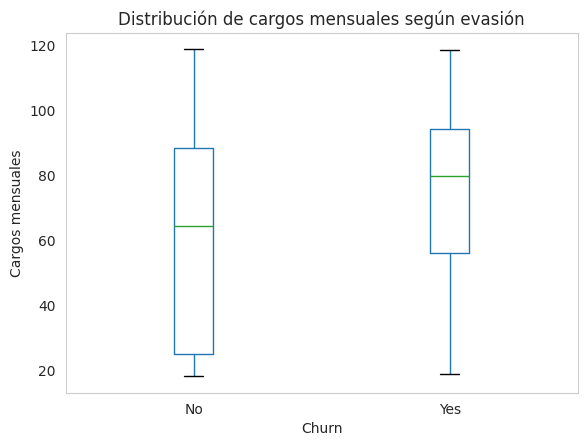

In [111]:
df_normalized.boxplot(column='account.Charges.Monthly', by='Churn', grid=False)
plt.title('Distribución de cargos mensuales según evasión')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Cargos mensuales')
plt.show()

Los clientes que abandonan el servicio presentan, en promedio, cargos mensuales más elevados. Esto sugiere que el costo del servicio puede influir en la decisión de abandono.

In [112]:
df_normalized.groupby('Churn')['account.Charges.Total'].describe()



,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,2549.911442,2329.954215,0.00,572.9,1679.525,4262.85,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.5,703.550,2331.30,8684.80


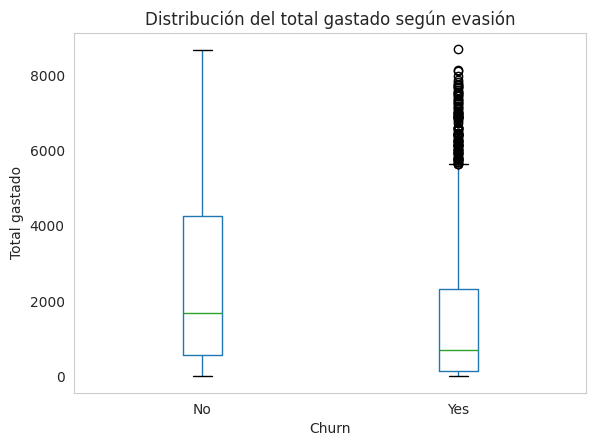

In [113]:


df_normalized.boxplot(column='account.Charges.Total', by='Churn', grid=False)
plt.title('Distribución del total gastado según evasión')
plt.suptitle('')
plt.xlabel('Churn')
plt.ylabel('Total gastado')
plt.show()

El total gastado suele estar asociado a la antigüedad: clientes con menor tenure tienden a acumular menor gasto total y concentran mayor evasión.

##📄Informe final

7.  Conclusiones finales: hallazgos clave, insights estratégicos y recomendaciones accionables

**Introduccion**

Para este proyecto, el objetivo principal fue entender por qué los clientes de Telecom X están abandonando la compañía. Tras limpiar la base de datos (donde encontramos varios errores de formato en los cobros totales), pudimos sacar conclusiones que van más allá de lo evidente.


**Limpieza y tratamientos de Datos**

* Se realizó la carga de archivo JSON desde API
* Dado que el archivo JSON poseía información anidada, se realizó la normalización para acceder a todas las columnas
* Se realizó una revisión inicial de los datos, que incorporaba mirar el DataFrame, conocer sus columnas y el tipo de dato que almacenaban, revisar los datos únicos, duplicados, nulos y vacíos.
* Se realizó una modificación de los tipos de datos donde correspondían, y una nueva limpieza de datos para eliminar todo dato que pudiera restar valor del análisis.
* Se incorporó una columna para costo diario

**Análisis exploratorio de Datos**

* Se realizó una exploración inicial del dataset utilizando el método .describe() tanto para variables numéricas como categóricas, con el objetivo de obtener una primera aproximación a la estructura y comportamiento de los datos.
* Posteriormente, el análisis se centró en la variable objetivo Churn. Se identificó que aproximadamente el 26.6% de los clientes de Telecom X han cancelado el servicio, lo que representa un nivel de evasión considerable.
* Al analizar la evasión según género, no se observan diferencias significativas entre hombres y mujeres, lo que sugiere que esta variable no parece ser un factor determinante en la cancelación del servicio.
*En cuanto al tipo de contrato, se detecta una concentración notable de evasión en clientes con contrato mensual. Esto indica que, a menor plazo de permanencia contractual, mayor es la probabilidad de cancelación.
* Respecto al método de pago, se observa una mayor proporción de churn en clientes que utilizan cheque electrónico, lo que podría estar asociado a perfiles con menor nivel de compromiso o estabilidad en el servicio.
* Al analizar el tipo de internet, se identifica una mayor concentración de cancelaciones en usuarios con fibra óptica, lo que sugiere la necesidad de profundizar en posibles factores asociados a este segmento.
* El análisis por tiempo de permanencia (tenure) muestra un patrón claro: la mayoría de las cancelaciones se concentran en clientes con pocos meses de antigüedad. Esto indica que el riesgo de evasión es más alto en las primeras etapas del ciclo de vida del cliente.
* De manera similar, al revisar el gasto total acumulado, se observa que aproximadamente el 50% de las cancelaciones corresponden a clientes con un gasto total igual o inferior a 500, lo cual está directamente relacionado con una menor permanencia en la empresa.
* Finalmente, se identifica un patrón combinado entre el tipo de contrato y el tipo de internet, lo que sugiere que la interacción entre variables podría estar influyendo en la probabilidad de evasión.

**Conclusión e Insights**

El análisis de evasión de clientes en Telecom X muestra que el churn no se distribuye de manera aleatoria, sino que sigue patrones claros asociados principalmente al nivel de compromiso contractual y al tiempo de permanencia.
La tasa general de evasión (26.6%) es relevante y representa una oportunidad importante de mejora en retención.

Los principales hallazgos indican que:

* El género no es un factor determinante en la cancelación del servicio.
* Los clientes con contrato mensual presentan la mayor probabilidad de evasión, lo que sugiere que la flexibilidad contractual reduce el compromiso.
* Existe una alta concentración de churn en clientes con pocos meses de permanencia, lo que indica que el riesgo es mayor en las primeras etapas del ciclo de vida.
* Los clientes con menor gasto acumulado (≤ 500) concentran aproximadamente la mitad de las cancelaciones, reforzando la relación entre baja antigüedad y mayor riesgo.
*El cheque electrónico como método de pago muestra mayor proporción de evasión.
* Se observa un patrón entre tipo de contrato y tipo de internet, lo que sugiere que ciertas combinaciones podrían estar elevando el riesgo de cancelación.

En conjunto, los resultados indican que el churn está más relacionado con el nivel de compromiso y la etapa temprana del cliente que con variables demográficas.

**Recomendaciones**

Estrategias para clientes nuevos (0–6 meses)

* Implementar programas de onboarding más sólidos.
* Ofrecer seguimiento personalizado durante los primeros meses.
* Incentivos por permanencia temprana (descuentos progresivos o beneficios acumulables).

Incentivar contratos de mayor plazo

* Promociones para migrar de contrato mensual a anual.
* Beneficios exclusivos para contratos de largo plazo.
* Descuentos por permanencia.

Analizar el segmento de cheque electrónico

* Evaluar si existe un perfil de riesgo financiero asociado.
* Ofrecer incentivos para cambiar a pago automático.
* Revisar posibles fricciones en el proceso de pago.

Profundizar en el caso de Fibra Óptica

* Evaluar calidad del servicio en este segmento.
* Analizar si el churn ocurre después de cierto tiempo específico.

